# AI for Molecules — Hands-on Tutorial

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Corteswain/AI4molecules-tutorial/blob/main/notebooks/AI4molecules_tutorial.ipynb)

In this 75-minute tutorial you'll build a molecular property predictor from scratch, making four modeling decisions in sequence:

0. **Dataset splitting** — how do we split data into train/test so our performance estimate is trustworthy? This comes first because it doesn't depend on anything else — it only touches the SMILES and the target, not any model or features.
1. **Model choice** — a classical ML model (Random Forest / XGBoost) on hand-crafted features, or a graph neural network (Chemprop) that learns its own representation? This determines whether the next step even applies.
2. **Representation** — how do we turn a molecule (a SMILES string) into numbers a model can use? (Only relevant if you didn't pick Chemprop — more on that below.)
3. **Train & evaluate** — put it all together and see how it did.

At each step, a few options are already implemented as functions in `utils/`. **You choose which one to plug in**, run it, and then we compare notes as a group before moving to the next step.

**Task:** predict aqueous solubility (logS) from molecular structure, using the [ESOL dataset](https://pubs.acs.org/doi/10.1021/ci034243x) (1,128 small molecules).

**Agenda (75 min)**

| Time | Section |
|---|---|
| 0–8 min | Setup |
| 8–28 min | Step 0: Splitting |
| 28–35 min | Step 1: Model choice |
| 35–49 min | Step 2: Representation |
| 49–66 min | Step 3: Train & evaluate |
| 66–75 min | Wrap-up & comparison |


## Setup

Run the cell below once. On Colab it installs the needed packages and pulls in the `utils/` code and dataset from the tutorial repo (takes ~1-2 minutes).

In [7]:
import sys
import os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !pip install -q rdkit scikit-learn xgboost chemprop pandas matplotlib
    if not os.path.exists("AI4molecules-tutorial"):
        !git clone --quiet https://github.com/Corteswain/AI4molecules-tutorial.git
    %cd AI4molecules-tutorial
else:
    # This notebook always lives at <repo_root>/notebooks/AI4molecules_tutorial.ipynb, so
    # the repo root is exactly one directory up from here. VS Code's Jupyter extension
    # exposes the notebook's own file path as __vsc_ipynb_file__ — we use that (not the
    # kernel's working directory, which VS Code does not set to the notebook's folder).
    os.chdir(Path(__vsc_ipynb_file__).resolve().parent.parent)

sys.path.insert(0, ".")
print("Setup done. Running in Colab:", IN_COLAB, "| working directory:", os.getcwd())

Setup done. Running in Colab: False | working directory: /home/ricbec/projects/AI4molecules-tutorial


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.representations import REPRESENTATIONS
from utils.splitting import SPLITTERS, random_split, scaffold_split, kmeans_split, butina_split
from utils.models import MODEL_RUNNERS, run_chemprop
from utils.viz import low_dimensional_representation, TRAIN_COLOR, TEST_COLOR

TARGET = "measured_log_solubility_mol_per_L"
df = pd.read_csv("data/esol.csv")
print(f"{len(df)} molecules")
df.head()

1128 molecules


,compound_id,smiles,measured_log_solubility_mol_per_L
0,Amigdalin,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77
1,Fenfuram,Cc1occc1C(=O)Nc2ccccc2,-3.30
2,citral,CC(C)=CCCC(C)=CC(=O),-2.06
3,Picene,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
4,Thiophene,c1ccsc1,-1.33


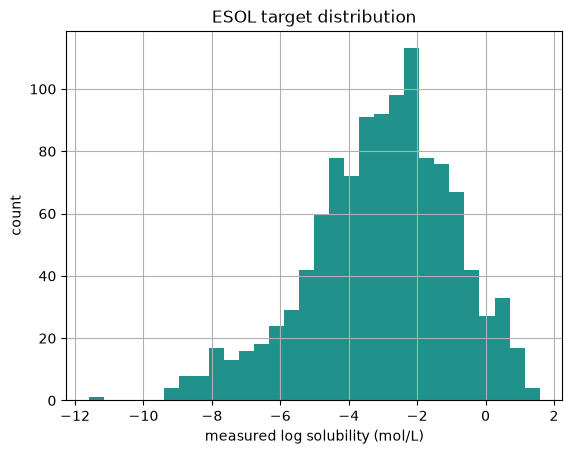

In [9]:
df[TARGET].hist(bins=30, color=plt.cm.viridis(0.5))
plt.xlabel("measured log solubility (mol/L)")
plt.ylabel("count")
plt.title("ESOL target distribution")
plt.show()

## Step 0 — Dataset splitting

We start here because splitting only touches the SMILES and the target — it doesn't depend on a
model or a representation, so there's no reason to decide those first. How we split molecules into
train/test changes what our evaluation actually measures. Four options are implemented in
`utils/splitting.py`:

- **`random`** — a plain i.i.d. shuffle-and-split. No relationship between molecules is considered.
- **`scaffold`** — molecules are grouped by [Bemis-Murcko scaffold](https://en.wikipedia.org/wiki/Bemis%E2%80%93Murcko_scaffold) (their shared ring/core structure); whole scaffold groups go to either train or test, so near-identical molecules can't leak across the split.
- **`kmeans`** — molecules are clustered by *Euclidean* distance between fingerprint vectors (KMeans), and whole clusters are held out for test.
- **`butina`** — molecules are clustered by *Tanimoto* similarity between fingerprints ([Butina clustering](https://www.rdkit.org/docs/Cookbook.html#clustering-molecules), the standard cheminformatics notion of "similar molecule"), and whole clusters are held out for test.

`kmeans` and `butina` both aim to test extrapolation to structurally distinct
regions of chemical space, but they can disagree with each other: two molecules "close" by
Euclidean distance aren't guaranteed to be "close" by Tanimoto similarity, especially near cluster
boundaries.

Rather than picking one blind, run the cell below to compute **all four splits** — each one is
called explicitly, with a short message when it's done, so you can see exactly which computation
is happening and how long each one takes.

In [10]:
print("Running random_split...")
random_train_idx, random_test_idx = random_split(df, test_size=0.2, seed=42)
print(f"  done — {len(random_train_idx)} train / {len(random_test_idx)} test")

print("Running scaffold_split...")
scaffold_train_idx, scaffold_test_idx = scaffold_split(df, test_size=0.2, seed=42)
print(f"  done — {len(scaffold_train_idx)} train / {len(scaffold_test_idx)} test")

print("Running kmeans_split...")
kmeans_train_idx, kmeans_test_idx = kmeans_split(df, test_size=0.2, seed=42)
print(f"  done — {len(kmeans_train_idx)} train / {len(kmeans_test_idx)} test")

print("Running butina_split...")
butina_train_idx, butina_test_idx = butina_split(df, test_size=0.2, seed=42)
print(f"  done — {len(butina_train_idx)} train / {len(butina_test_idx)} test")

splits = {
    "random": (random_train_idx, random_test_idx),
    "scaffold": (scaffold_train_idx, scaffold_test_idx),
    "kmeans": (kmeans_train_idx, kmeans_test_idx),
    "butina": (butina_train_idx, butina_test_idx),
}

Running random_split...
  done — 903 train / 225 test
Running scaffold_split...
  done — 811 train / 317 test
Running kmeans_split...
  done — 934 train / 194 test
Running butina_split...
  done — 943 train / 185 test


Now pick one of the four to inspect more closely.

Using scaffold: 811 train / 317 test


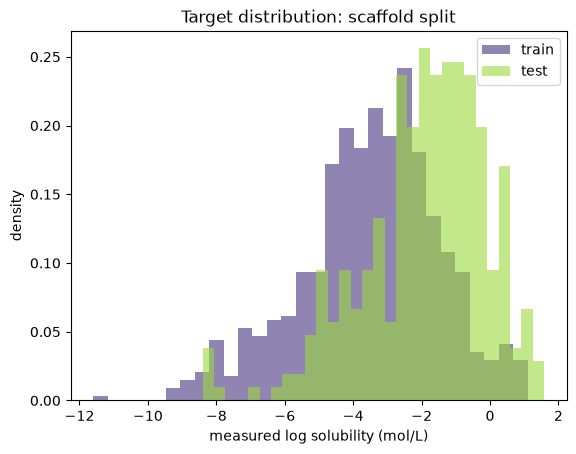

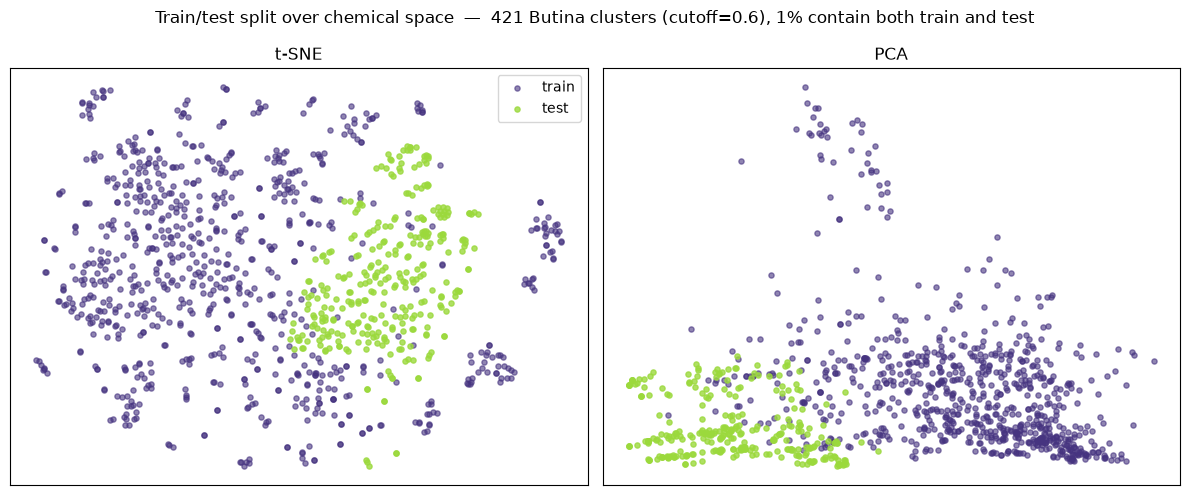

3/421 Butina clusters (1%) contain both train and test molecules.


In [18]:
# ---- YOUR CHOICE ----
SPLIT_METHOD = "scaffold"  # options: "random", "scaffold", "kmeans", "butina"
# ----------------------

train_idx, test_idx = splits[SPLIT_METHOD]
train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)
y_train, y_test = df[TARGET].values[train_idx], df[TARGET].values[test_idx]

print(f"Using {SPLIT_METHOD}: {len(train_idx)} train / {len(test_idx)} test")

plt.hist(y_train, bins=30, alpha=0.6, label="train", density=True, color=TRAIN_COLOR)
plt.hist(y_test, bins=30, alpha=0.6, label="test", density=True, color=TEST_COLOR)
plt.xlabel("measured log solubility (mol/L)")
plt.ylabel("density")
plt.legend()
plt.title(f"Target distribution: {SPLIT_METHOD} split")
plt.show()

split_stats = low_dimensional_representation(df, train_idx, test_idx)

**Discuss:**
- Do train and test look like they come from the same distribution (histogram) and occupy the same regions of chemical space (t-SNE/PCA)?
- What fraction of Butina clusters contain both train and test molecules? What would you expect that number to be for each split method, and does the plot match?
- Try switching `SPLIT_METHOD` to `kmeans` and re-run from there — both it and `butina` "hold out whole clusters," so why doesn't `kmeans` also drive the mixed-cluster fraction to 0%?
- With `scaffold` or either `cluster_*` method, are you testing *interpolation* (molecules similar to what the model has seen) or *extrapolation* (genuinely new chemistry)?
- Which split would you trust more as an estimate of performance on molecules made in a lab next year?

## Step 1 — Model choice

Now that the split is fixed, decide which model to train. This choice determines whether
hand-crafting features (Step 2) is even part of the workflow. Three options are implemented in
`utils/models.py`:

- **`random_forest`** / **`xgboost`** — classical ML models. They need a fixed-size feature vector
  per molecule, which means *you* have to decide how to turn a molecule into numbers (Step 2).
- **`chemprop`** — a message-passing graph neural network (MPNN) that learns its own representation
  directly from the molecular graph, end to end, while training. It **skips Step 2 entirely** — there's
  no separate featurization step because feature-crafting is folded into the model itself.

Pick one below. (Chemprop takes ~20-40 seconds to train, later in Step 3.)

In [12]:
# ---- YOUR CHOICE ----
MODEL = "random_forest"  # options: "random_forest", "xgboost", "chemprop"
# ----------------------

print(f"Selected model: {MODEL}")
if MODEL == "chemprop":
    print("Chemprop learns its own representation from the molecular graph — Step 2 (Representation) won't apply.")

Selected model: random_forest


**Discuss:**
- Random Forest and XGBoost are trained on a fixed feature vector — what does that assume about the features you'll pick in Step 2?
- Chemprop trains directly on the molecular graph. What does it need *more* of (data, compute, time) to make up for not having hand-crafted features?
- If you only had 50 molecules instead of ~1,000, would your choice of model change?

## Step 2 — Representation

**Skip this step if you picked `chemprop` in Step 1** — it learns its own representation directly
from the molecular graph, so there's nothing to hand-craft here. For `random_forest` / `xgboost`,
pick how to turn a molecule into numbers. Three options are implemented in `utils/representations.py`:

- **`morgan`** — Morgan (circular) fingerprints: a 2048-bit vector encoding which local substructures are present.
- **`maccs`** — MACCS keys: a fixed 166-bit vector, each bit a specific, human-named structural pattern (e.g. "has a ring of size 6").
- **`rdkit_descriptors`** — a handful of global physicochemical descriptors: molecular weight, LogP, TPSA, H-bond donors/acceptors, rotatable bonds, ring counts...

Pick one below.

In [13]:
# ---- YOUR CHOICE ----
REPRESENTATION = "morgan"  # options: "morgan", "maccs", "rdkit_descriptors"
# ----------------------

if MODEL == "chemprop":
    print("MODEL = 'chemprop' — it builds its own representation from the graph, so this choice will be ignored in Step 3.")
    X_train = X_test = None
else:
    featurize = REPRESENTATIONS[REPRESENTATION]
    X_train = featurize(train_df["smiles"].tolist())
    X_test = featurize(test_df["smiles"].tolist())
    print(f"{REPRESENTATION}: X_train.shape = {X_train.shape}")

morgan: X_train.shape = (903, 2048)


**Discuss:**
- How many numbers describe each molecule here? What structural information might this representation lose?
- Would two molecules a chemist considers very similar end up with similar feature vectors?
- Could you look at this feature vector and explain *why* the model made a given prediction?

## Step 3 — Train & evaluate

Now put your three choices together: train `MODEL` on the `SPLIT_METHOD` split, using the
`REPRESENTATION` features (unless you picked `chemprop`, which trains directly on SMILES).

In [14]:
if MODEL == "chemprop":
    # Chemprop's "representation learning" is, in effect, its own version of Step 2 —
    # it folds feature-crafting into the model rather than doing it by hand.
    result = run_chemprop(train_df, test_df, target_col=TARGET, epochs=30)
    label = f"{MODEL} ({SPLIT_METHOD} split, learned representation)"
else:
    result = MODEL_RUNNERS[MODEL](X_train, y_train, X_test, y_test)
    label = f"{MODEL} ({SPLIT_METHOD} split, {REPRESENTATION} representation)"

print(label)
print(f"RMSE = {result['rmse']:.3f}   R2 = {result['r2']:.3f}")

random_forest (random split, morgan representation)
RMSE = 1.178   R2 = 0.708


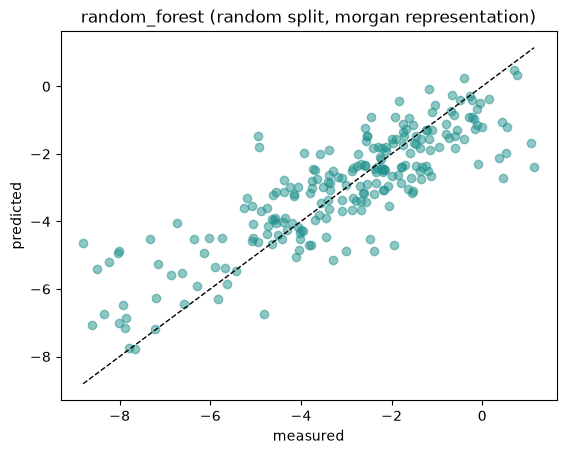

In [15]:
y_pred = result["y_pred"]
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.scatter(y_test, y_pred, alpha=0.5, color=plt.cm.viridis(0.5))
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlabel("measured")
plt.ylabel("predicted")
plt.title(label)
plt.show()

**Discuss:**
- How does your RMSE/R² compare to what your neighbor got with a different choice at any step?
- Random Forest / XGBoost only ever see the Step 2 features — if performance is poor, is that the model's fault or the representation's?
- Chemprop folded feature-crafting into the model itself. Did it do better or worse than the hand-crafted features here? (Hint: ESOL's target was historically fit using a formula built from LogP, molecular weight, and aromaticity — some of the exact descriptors in `rdkit_descriptors`.) What are the benefits and drawbacks of letting a model *learn* its own representation instead of hand-designing one?

## Bonus — compare every combination

If time allows, run the two cells below to sweep every (representation × split × model) combination and compare them side by side. The classical combinations run in seconds; adding chemprop across all three splits takes roughly a minute more.

In [16]:
y_all = df[TARGET].values

results = []
for rep_name in REPRESENTATIONS:
    Xa = REPRESENTATIONS[rep_name](df["smiles"].tolist())
    for split_name in SPLITTERS:
        tr_idx, te_idx = SPLITTERS[split_name](df, test_size=0.2, seed=42)
        Xtr, Xte = Xa[tr_idx], Xa[te_idx]
        ytr, yte = y_all[tr_idx], y_all[te_idx]
        for model_name in MODEL_RUNNERS:
            r = MODEL_RUNNERS[model_name](Xtr, ytr, Xte, yte)
            results.append({
                "representation": rep_name, "split": split_name, "model": model_name,
                "rmse": r["rmse"], "r2": r["r2"],
            })

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
results_df

KeyboardInterrupt: 

In [ ]:
# Optional: also benchmark chemprop across each split (~1 minute total)
for split_name in SPLITTERS:
    tr_idx, te_idx = SPLITTERS[split_name](df, test_size=0.2, seed=42)
    tr_df = df.iloc[tr_idx].reset_index(drop=True)
    te_df = df.iloc[te_idx].reset_index(drop=True)
    r = run_chemprop(tr_df, te_df, target_col=TARGET, epochs=30)
    results.append({
        "representation": "learned (chemprop)", "split": split_name, "model": "chemprop",
        "rmse": r["rmse"], "r2": r["r2"],
    })

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
results_df

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
labels = results_df["representation"] + " / " + results_df["split"] + " / " + results_df["model"]
ax.barh(labels, results_df["rmse"], color=plt.cm.viridis(np.linspace(0, 1, len(results_df))))
ax.set_xlabel("RMSE (lower is better)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Wrap-up

Today you made three modeling decisions and saw how each one changes what "good performance" even means:

- **Splitting** shapes what question your evaluation is actually answering — interpolation vs. extrapolation.
- **Model choice** determines whether feature-crafting is even a separate decision: Random Forest and XGBoost need you to hand-design good features; Chemprop folds that decision into the model itself, learning a representation end-to-end.
- **Representation** (when it applies) shapes what information is available to the model at all.

**Keep exploring:**
- Try other [MoleculeNet](https://moleculenet.org/) datasets (BBBP, Tox21, FreeSolv) with the same functions.
- Add hyperparameter tuning (`GridSearchCV`, or Chemprop's `--depth` / `--hidden-size` / `--epochs`).
- Open `utils/representations.py`, `utils/splitting.py`, `utils/models.py` to see how each function is implemented, and try writing your own.

Repo: https://github.com/Corteswain/AI4molecules-tutorial